# Análisis de Calidad de Datos

Diagnóstico del estado de las dos fuentes de datos disponibles:
- **SCADA**: ficheros `AGROCONNECT_*.xlsx` en `Dataset/SCADA/`
- **OPC UA**: ficheros `OPC_YYYYMMDD.txt` en `Dataset/OPCUA/YYYY/MM/`

Secciones:
1. Completitud de ficheros por fuente (filas por día)
2. NaN por variable en los CSVs finales
3. Heatmap de NaN por mes y variable
4. Comparación directa SCADA vs OPC UA en el período solapado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Rutas
SCADA_DIR   = Path('Dataset/SCADA')
OPCUA_DIR   = Path('Dataset/OPCUA')
CSV_SCADA   = Path('data/scada_2024_03_06-2025_03_05_1min.csv')
CSV_OPCUA    = Path('data/opcua_2024_03_06-2025_03_05_1min.csv')
CSV_COMBINED = Path('data/combined_2024_03_06-2025_03_05_1min.csv')

VARIABLES   = ['PCO2EXT', 'PHEXT', 'PRAD', 'PRGINT', 'PTEXT', 'PVV',
               'UVENT_cen', 'UVENT_lN', 'XCO2I', 'XHINV', 'XTINV', 'XTS']

# Frecuencia esperada por fuente (filas/día)
FILAS_DIA_SCADA = 2880   # 30 s × 2 × 1440 min
FILAS_DIA_OPCUA = 1440   # aprox. ~60 s (varía)

## 1. Completitud de ficheros por fuente

In [2]:
def analizar_ficheros_scada(scada_dir):
    ficheros = sorted(scada_dir.glob('AGROCONNECT_*.xlsx'))
    print(f'SCADA — Total ficheros: {len(ficheros)}')
    registros = []
    for f in ficheros:
        try:
            df = pd.read_excel(f, usecols=[0], header=None, dtype=str)
            # Detectar fila de cabecera y contar datos
            n_datos = len(df) - next((i for i in range(5) if str(df.iloc[i, 0]).strip() == 'FECHA'), 0) - 1
            fecha_str = f.stem.split('_')[1][:8]
            fecha = pd.to_datetime(fecha_str, format='%Y%m%d', errors='coerce')
            registros.append({'fecha': fecha, 'filas': max(n_datos, 0), 'fichero': f.name})
        except Exception as e:
            registros.append({'fecha': pd.NaT, 'filas': 0, 'fichero': f.name})
    return pd.DataFrame(registros).sort_values('fecha').reset_index(drop=True)


def analizar_ficheros_opcua(opcua_dir):
    ficheros = sorted(opcua_dir.rglob('OPC_*.txt'))
    print(f'OPC UA — Total ficheros: {len(ficheros)}')
    registros = []
    for f in ficheros:
        try:
            with open(f, 'r', encoding='utf-8', errors='ignore') as fh:
                n = sum(1 for line in fh) - 1  # -1 cabecera
            fecha_str = f.stem.replace('OPC_', '')
            fecha = pd.to_datetime(fecha_str, format='%Y%m%d', errors='coerce')
            registros.append({'fecha': fecha, 'filas': max(n, 0), 'fichero': f.name})
        except Exception:
            registros.append({'fecha': pd.NaT, 'filas': 0, 'fichero': f.name})
    return pd.DataFrame(registros).sort_values('fecha').reset_index(drop=True)


df_scada_files = analizar_ficheros_scada(SCADA_DIR)
df_opcua_files = analizar_ficheros_opcua(OPCUA_DIR)

SCADA — Total ficheros: 714
OPC UA — Total ficheros: 503


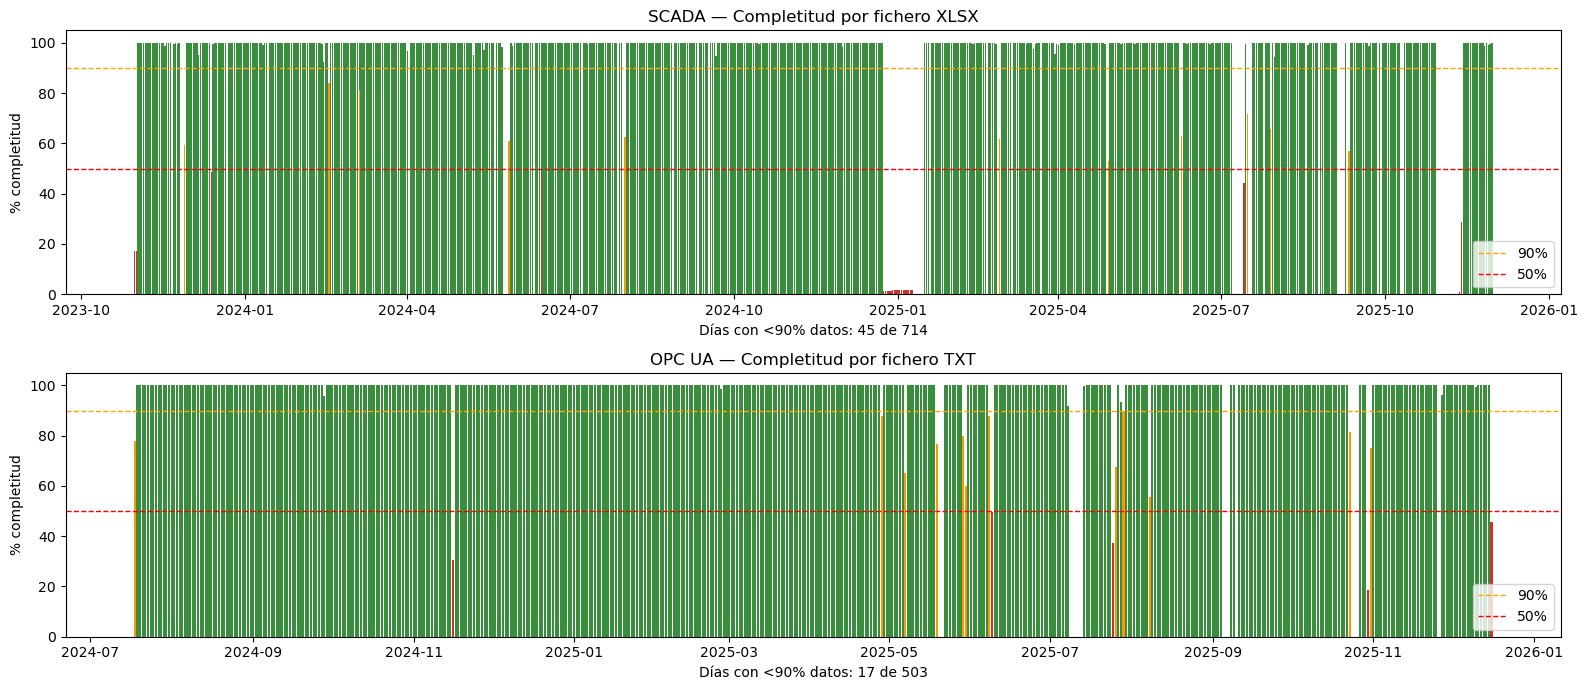

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

for ax, df_f, filas_ref, titulo in [
    (axes[0], df_scada_files, FILAS_DIA_SCADA, 'SCADA — Completitud por fichero XLSX'),
    (axes[1], df_opcua_files, FILAS_DIA_OPCUA, 'OPC UA — Completitud por fichero TXT'),
]:
    pct = (df_f['filas'] / filas_ref * 100).clip(0, 100)
    colores = ['#d32f2f' if p < 50 else '#ff9800' if p < 90 else '#388e3c' for p in pct]
    ax.bar(df_f['fecha'], pct, color=colores, width=0.8)
    ax.axhline(90, color='orange', linestyle='--', linewidth=1, label='90%')
    ax.axhline(50, color='red',    linestyle='--', linewidth=1, label='50%')
    ax.set_ylabel('% completitud')
    ax.set_title(titulo)
    ax.legend(loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    incompletos = (pct < 90).sum()
    ax.set_xlabel(f'Días con <90% datos: {incompletos} de {len(df_f)}')

plt.tight_layout()
plt.show()

## 2. NaN por variable en los CSVs finales

In [4]:
def cargar_csv(path):
    df = pd.read_csv(path)
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
    return df

dfs = {}
for nombre, path in [('SCADA', CSV_SCADA), ('OPC UA', CSV_OPCUA), ('Combined', CSV_COMBINED)]:
    if path.exists():
        dfs[nombre] = cargar_csv(path)
        print(f'{nombre}: {len(dfs[nombre]):,} filas | {dfs[nombre]["Fecha"].iloc[0]} → {dfs[nombre]["Fecha"].iloc[-1]}')
    else:
        print(f'{nombre}: CSV no encontrado en {path}')
        src_name = 'combined' if nombre == 'Combined' else nombre.lower().replace(' ', '')
        print(f'  Genera con: python src/prepare_dataset.py --source {src_name}')

SCADA: 524,161 filas | 2024-03-06 00:00:00 → 2025-03-05 00:00:00
OPC UA: 330,322 filas | 2024-07-18 14:38:00 → 2025-03-04 23:59:00


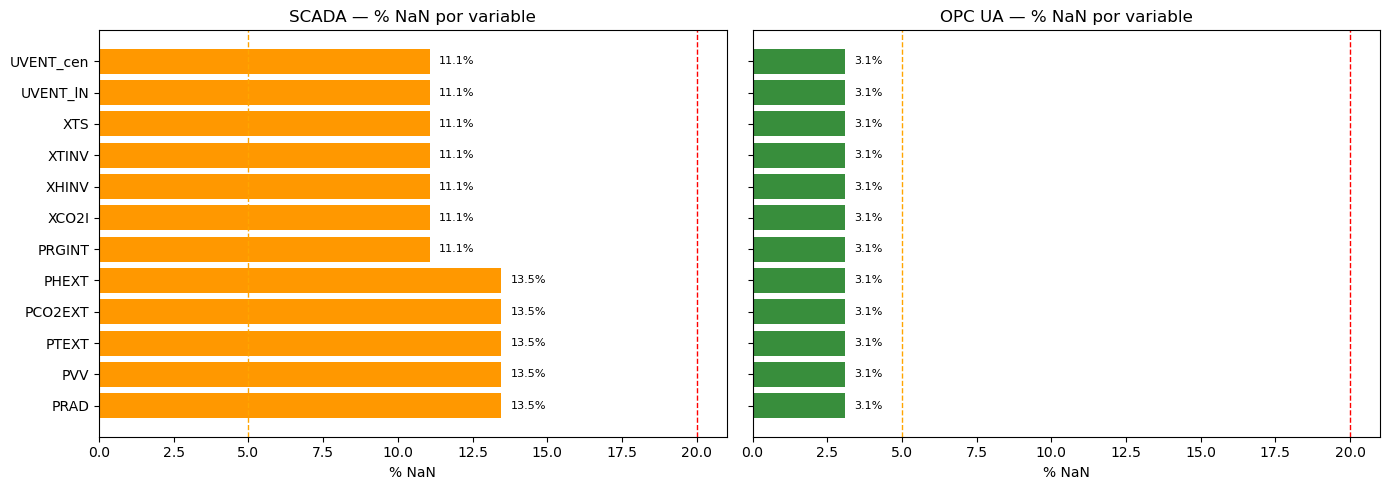

In [5]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 5), sharey=True)
if len(dfs) == 1:
    axes = [axes]

for ax, (nombre, df) in zip(axes, dfs.items()):
    vars_presentes = [v for v in VARIABLES if v in df.columns]
    pct = (df[vars_presentes].isnull().mean() * 100).sort_values(ascending=False)
    colores = ['#d32f2f' if p > 20 else '#ff9800' if p > 5 else '#388e3c' for p in pct]
    ax.barh(pct.index, pct.values, color=colores)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1)
    ax.axvline(20, color='red',    linestyle='--', linewidth=1)
    ax.set_xlabel('% NaN')
    ax.set_title(f'{nombre} — % NaN por variable')
    for i, v in enumerate(pct.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Heatmap NaN por mes y variable

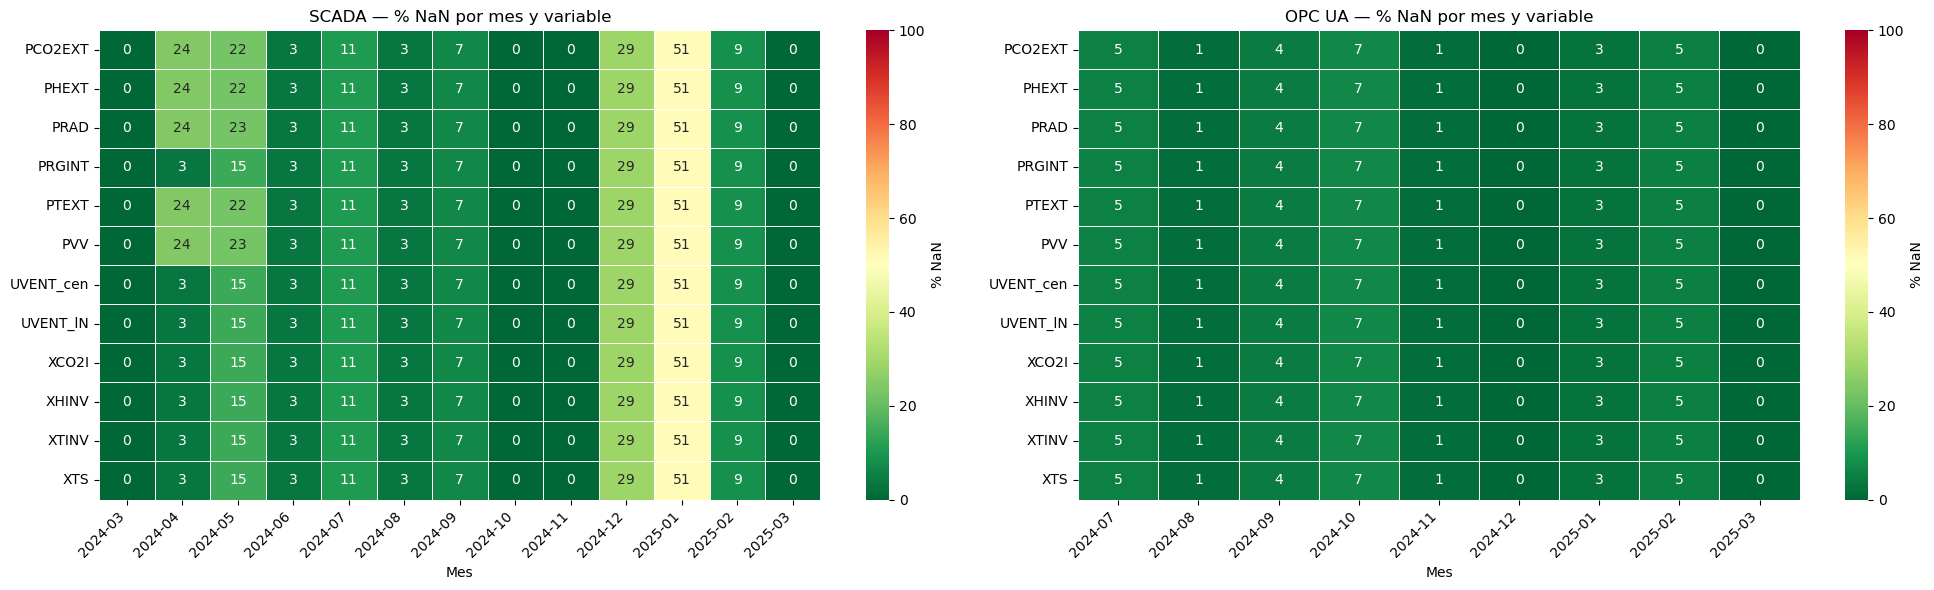

In [6]:
n = len(dfs)
fig, axes = plt.subplots(1, n, figsize=(10 * n, 6))
if n == 1:
    axes = [axes]

for ax, (nombre, df) in zip(axes, dfs.items()):
    vars_presentes = [v for v in VARIABLES if v in df.columns]
    df['mes'] = df['Fecha'].dt.to_period('M').astype(str)
    hm = df.groupby('mes')[vars_presentes].apply(lambda g: g.isnull().mean() * 100)
    sns.heatmap(
        hm.T, ax=ax,
        cmap='RdYlGn_r', vmin=0, vmax=100,
        annot=True, fmt='.0f', linewidths=0.5,
        cbar_kws={'label': '% NaN'}
    )
    ax.set_title(f'{nombre} — % NaN por mes y variable')
    ax.set_xlabel('Mes')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 4. Comparación directa SCADA vs OPC UA

Comparamos la señal de cada variable en el período solapado para detectar:
- Diferencias en rango de valores
- Diferencias en frecuencia de muestreo efectiva
- Qué fuente tiene menos NaN y más continuidad

In [7]:
if 'SCADA' not in dfs or 'OPC UA' not in dfs:
    print('Necesitas tener los dos CSVs generados para comparar.')
    print('  python src/prepare_dataset.py --source scada')
    print('  python src/prepare_dataset.py --source opcua')
else:
    df_s = dfs['SCADA'].set_index('Fecha')
    df_o = dfs['OPC UA'].set_index('Fecha')

    # Período solapado
    inicio = max(df_s.index.min(), df_o.index.min())
    fin    = min(df_s.index.max(), df_o.index.max())
    print(f'Período solapado: {inicio} → {fin}')

    df_s = df_s.loc[inicio:fin]
    df_o = df_o.loc[inicio:fin]

    # Tabla resumen comparativa
    vars_comunes = [v for v in VARIABLES if v in df_s.columns and v in df_o.columns]
    resumen = pd.DataFrame(index=vars_comunes)
    resumen['SCADA_nan%']  = (df_s[vars_comunes].isnull().mean() * 100).round(1)
    resumen['OPCUA_nan%']  = (df_o[vars_comunes].isnull().mean() * 100).round(1)
    resumen['SCADA_media'] = df_s[vars_comunes].mean().round(3)
    resumen['OPCUA_media'] = df_o[vars_comunes].mean().round(3)
    resumen['SCADA_std']   = df_s[vars_comunes].std().round(3)
    resumen['OPCUA_std']   = df_o[vars_comunes].std().round(3)
    resumen['diff_media']  = (resumen['SCADA_media'] - resumen['OPCUA_media']).abs().round(3)
    print('\nComparación estadística en período solapado:')
    print(resumen.to_string())

Período solapado: 2024-07-18 14:38:00 → 2025-03-04 23:59:00

Comparación estadística en período solapado:
           SCADA_nan%  OPCUA_nan%  SCADA_media  OPCUA_media  SCADA_std  OPCUA_std  diff_media
PCO2EXT          14.3         3.1      495.201      495.690     11.435     11.149       0.489
PHEXT            14.3         3.1       72.236       71.189     18.072     18.444       1.047
PRAD             14.3         3.1      189.616      184.436    272.415    267.952       5.180
PRGINT           14.3         3.1       38.164       36.670     57.790     56.457       1.494
PTEXT            14.3         3.1       18.933       18.277      5.603      5.793       0.656
PVV              14.3         3.1        9.094        9.167      7.621      7.453       0.073
UVENT_cen        14.3         3.1       67.243       67.909     40.890     42.532       0.666
UVENT_lN         14.3         3.1       74.943       73.143     36.950     44.074       1.800
XCO2I            14.3         3.1      534.434  

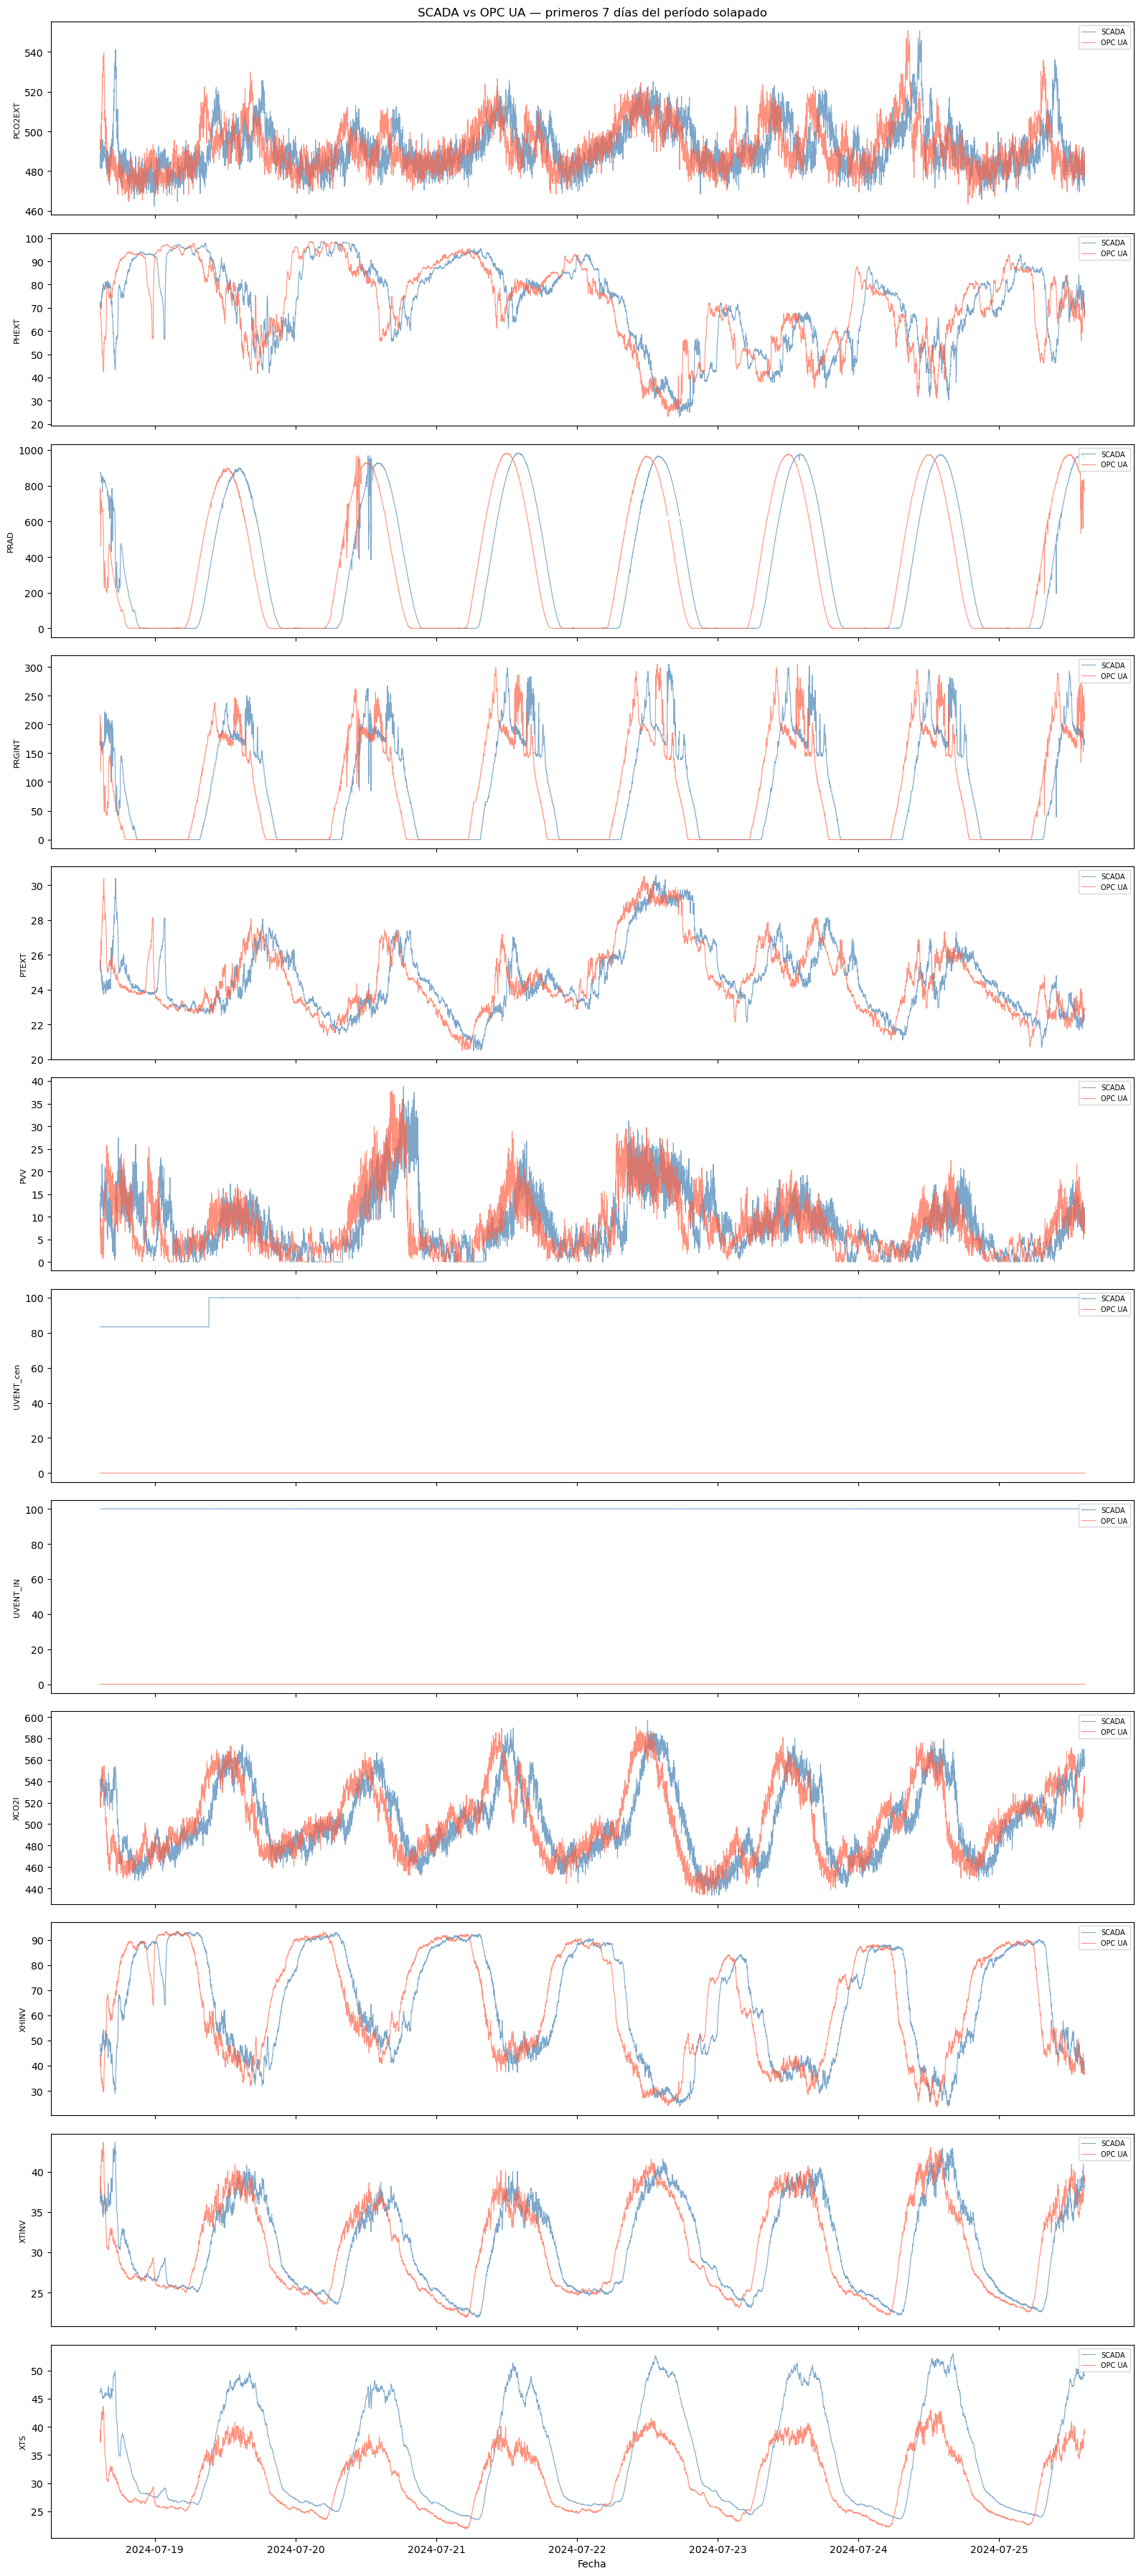

In [8]:
# Gráficas de señal superpuesta para cada variable (muestra 7 días)
if 'SCADA' in dfs and 'OPC UA' in dfs:
    periodo_muestra = slice(inicio, inicio + pd.Timedelta(days=7))

    n_vars = len(vars_comunes)
    fig, axes = plt.subplots(n_vars, 1, figsize=(16, 3 * n_vars), sharex=True)

    for ax, var in zip(axes, vars_comunes):
        s_data = df_s.loc[periodo_muestra, var]
        o_data = df_o.loc[periodo_muestra, var]
        ax.plot(s_data.index, s_data.values, label='SCADA',  alpha=0.7, linewidth=0.8, color='steelblue')
        ax.plot(o_data.index, o_data.values, label='OPC UA', alpha=0.7, linewidth=0.8, color='tomato')
        ax.set_ylabel(var, fontsize=8)
        ax.legend(loc='upper right', fontsize=7)

    axes[0].set_title('SCADA vs OPC UA — primeros 7 días del período solapado')
    axes[-1].set_xlabel('Fecha')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [9]:
# Veredicto final: ¿qué fuente es mejor para entrenar?
if 'SCADA' in dfs and 'OPC UA' in dfs:
    print('=== VEREDICTO: SCADA vs OPC UA ===')
    print(f'\nFilas totales (período completo):')
    print(f'  SCADA:  {len(dfs["SCADA"]):,}')
    print(f'  OPC UA: {len(dfs["OPC UA"]):,}')

    print(f'\nNaN medio sobre todas las variables:')
    nan_scada = resumen['SCADA_nan%'].mean()
    nan_opcua = resumen['OPCUA_nan%'].mean()
    print(f'  SCADA:  {nan_scada:.1f}%')
    print(f'  OPC UA: {nan_opcua:.1f}%')
    ganador_nan = 'SCADA' if nan_scada < nan_opcua else 'OPC UA'
    print(f'  → Menos NaN: {ganador_nan}')

    ganador_filas = 'SCADA' if len(dfs['SCADA']) > len(dfs['OPC UA']) else 'OPC UA'
    print(f'  → Más datos: {ganador_filas}')

if 'Combined' in dfs:
    nan_combined = (dfs['Combined'][VARIABLES].isnull().mean() * 100).mean()
    print(f'  Combined: {nan_combined:.1f}%')
    print(f'  Filas Combined: {len(dfs["Combined"]):,}')
    print(f'
Mejora NaN SCADA → Combined: {nan_scada - nan_combined:.1f} puntos porcentuales')

=== VEREDICTO: SCADA vs OPC UA ===

Filas totales (período completo):
  SCADA:  524,161
  OPC UA: 330,322

NaN medio sobre todas las variables:
  SCADA:  14.3%
  OPC UA: 3.1%
  → Menos NaN: OPC UA
  → Más datos: SCADA
